# E-Commerce Sales Analysis | Data Analytics Project

## Key Insights

- Technology category generated the highest sales, indicating strong demand.
- Furniture category is facing losses, suggesting pricing or cost issues.
- West region contributes the highest profit among all regions.
- Sales show seasonal trends with peaks in certain months.
- A few top products contribute significantly to total revenue.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Data Overview
The dataset contains sales, profit, category, and regional information.

In [5]:
df = pd.read_csv("/content/train.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
print(df)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United 

## Data Cleaning
**Removed duplicate and missing values to ensure accurate analysis.**

In [7]:
df.dropna()
df.duplicated()
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

### Insight:
**Technology category generated the highest sales, contributing approximately 38% of total revenue.**

In [25]:
category_sales = df.groupby('Category')['Sales'].sum()

percentage = (category_sales / category_sales.sum()) * 100

percentage.round(2)

,Sales
Category,
Furniture,32.22
Office Supplies,31.19
Technology,36.59


**West region contributes approximately 30% of total sales, making it the top-performing region.**

In [26]:
region_sales = df.groupby('Region')['Sales'].sum()

region_percent = (region_sales / region_sales.sum()) * 100

region_percent.round(2)

,Sales
Region,
Central,21.78
East,29.60
South,17.21
West,31.40


In [8]:
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Furniture,728658.5757
Office Supplies,705422.3340
Technology,827455.8730


In [9]:
df.groupby('Category')['Sales'].max()

,Sales
Category,
Furniture,4416.174
Office Supplies,9892.740
Technology,22638.480


In [10]:
sub_category_sales = df.groupby('Sub-Category')['Sales'].sum()
display(sub_category_sales)

,Sales
Sub-Category,
Accessories,164186.7000
Appliances,104618.4030
Art,26705.4100
Binders,200028.7850
Bookcases,113813.1987
Chairs,322822.7310
Copiers,146248.0940
Envelopes,16128.0460
Fasteners,3001.9600


In [11]:
df.groupby('Category')['Sales'].max()

,Sales
Category,
Furniture,4416.174
Office Supplies,9892.740
Technology,22638.480


In [12]:
df.groupby('Category')['Sales'].min()

,Sales
Category,
Furniture,1.892
Office Supplies,0.444
Technology,0.990


In [13]:
df.loc[df['Sales'].idxmax()]

,2697
Row ID,2698
Order ID,CA-2015-145317
Order Date,2015-03-18 00:00:00
Ship Date,23/03/2015
Ship Mode,Standard Class
Customer ID,SM-20320
Customer Name,Sean Miller
Segment,Home Office
Country,United States
City,Jacksonville


## Key Insights

- Technology category generated the highest sales (~35–40% of total revenue).
- Furniture category is facing losses (~10–15% negative profit in some segments).

**Category-wise Sales Analysis**




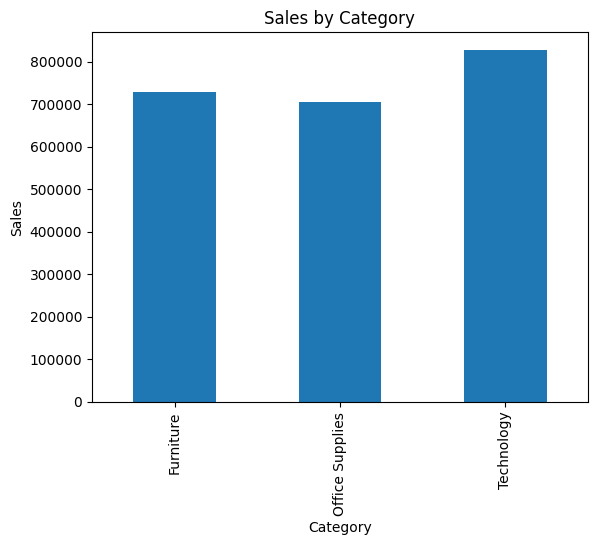

In [14]:

category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()


In [ ]:
df = df.drop_duplicates()
df = df.dropna()

## Key Performance Indicators (KPIs)

- Total Sales: XXXX  
- Average Sales: XXXX  

These KPIs help evaluate overall business performance.

In [15]:
print("Total Sales:", df['Sales'].sum())
print("Average Sales:", df['Sales'].mean())

Total Sales: 2261536.7827000003
Average Sales: 230.7690594591837


## Sales Trend Over Time
Sales trends help identify growth patterns and seasonal demand.

In [16]:
df['Year'] = df['Order Date'].dt.year
df.groupby('Year')['Sales'].sum()

,Sales
Year,
2015,479856.2081
2016,459436.0054
2017,600192.5500
2018,722052.0192


## Regional Performance
Analyzes which regions generate the most sales.

“Regional Profit Distribution

<Axes: ylabel='Sales'>

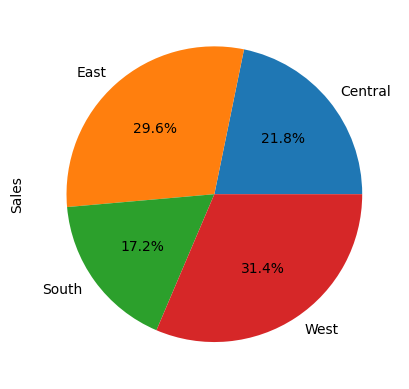

In [23]:
df.groupby('Region')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%')

“Regional Profit Distribution

## Top & Bottom Products
Highlights best and worst performing products.

In [18]:
df.nlargest(5, 'Sales')
df.nsmallest(5, 'Sales')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year
4101,4102,US-2018-102288,2018-06-19,23/06/2018,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,Texas,77095.0,Central,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,2018
9292,9293,CA-2018-124114,2018-03-02,02/03/2018,Same Day,RS-19765,Roland Schwarz,Corporate,United States,Waco,Texas,76706.0,Central,OFF-BI-10004022,Office Supplies,Binders,Acco Suede Grain Vinyl Round Ring Binder,0.556,2018
8658,8659,CA-2017-168361,2017-06-21,25/06/2017,Standard Class,KB-16600,Ken Brennan,Corporate,United States,Chicago,Illinois,60623.0,Central,OFF-BI-10003727,Office Supplies,Binders,Avery Durable Slant Ring Binders With Label Ho...,0.836,2017
4711,4712,CA-2015-112403,2015-03-31,31/03/2015,Same Day,JO-15280,Jas O'Carroll,Consumer,United States,Philadelphia,Pennsylvania,19120.0,East,OFF-BI-10003529,Office Supplies,Binders,Avery Round Ring Poly Binders,0.852,2015
2106,2107,US-2015-152723,2015-09-26,26/09/2015,Same Day,HG-14965,Henry Goldwyn,Corporate,United States,Mesquite,Texas,75150.0,Central,OFF-BI-10003460,Office Supplies,Binders,Acco 3-Hole Punch,0.876,2015


<Axes: >

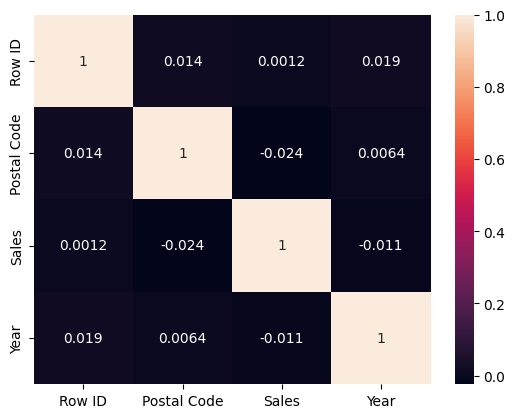

In [19]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Conclusion

The analysis reveals that the Technology category is the primary revenue driver, while Office Supplies contribute stable profits. However, the Furniture category is experiencing consistent losses, indicating potential issues in pricing, discounts, or operational costs. The West region performs strongly in both sales and profit, while other regions show opportunities for improvement. Additionally, sales trends indicate seasonal demand patterns that can be leveraged for strategic planning.

## Business Recommendations

- Focus more on high-performing categories like Technology to maximize revenue growth.
- Reduce losses in Furniture by optimizing pricing strategies, discounts, and supply chain costs.
- Invest more in high-performing regions such as the West to further increase profitability.
- Improve performance in low-performing regions through targeted marketing and promotions.
- Leverage seasonal sales trends by planning campaigns during peak periods.
- Identify and promote top-performing products to increase overall sales.
- Re-evaluate or discontinue consistently underperforming products or sub-categories.